# 📊 Data Loading and Initial Exploration

## 1. Dataset Loading
The dataset was successfully loaded using pandas.

- Total Rows: 6000  
- Total Columns: 20  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy import stats

df = pd.read_csv('Foodpanda Analysis Dataset.csv')

print("Dataset Loaded Successfully!")
print("-" * 30)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset Loaded Successfully!
------------------------------
Total Rows: 6000
Total Columns: 20


## 2. Data Summary

### 🔢 Numeric Features Summary
Statistical summary of numerical columns was generated using `describe()`:
- Includes: mean, standard deviation, min, max, quartiles
- Key features: `quantity`, `price`, `order_frequency`, `loyalty_points`, `rating`

### 🔤 Categorical Features Summary
Summary of categorical columns using `describe(include='object')`:
- Includes: count, unique values, most frequent (top), and frequency
- Features include: `gender`, `city`, `restaurant_name`, `payment_method`, etc.


In [2]:
print("--- Numeric Data Summary ---")
display(df.describe())

print("\n--- Categorical Data Summary ---")
display(df.describe(include='object'))

--- Numeric Data Summary ---


,quantity,price,order_frequency,loyalty_points,rating
count,6000.000000,6000.000000,6000.000000,6000.000000,4032.000000
mean,2.991667,800.524880,25.304667,250.173667,3.012153
std,1.414778,404.855029,14.358930,144.608478,1.411615
min,1.000000,100.300000,1.000000,0.000000,1.000000
25%,2.000000,441.997500,13.000000,125.000000,2.000000
50%,3.000000,806.460000,25.000000,249.500000,3.000000
75%,4.000000,1149.737500,37.000000,378.000000,4.000000
max,5.000000,1499.950000,50.000000,500.000000,5.000000



--- Categorical Data Summary ---


,customer_id,gender,age,city,signup_date,order_id,order_date,restaurant_name,dish_name,category,payment_method,last_order_date,churned,rating_date,delivery_status
count,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
unique,6000,3,3,5,730,6000,730,5,5,5,3,366,2,366,3
top,C5663,Female,Teenager,Multan,10/18/2023,O9663,9/8/2024,Subway,Pasta,Italian,Cash,8/13/2025,Active,6/14/2025,Delivered
freq,1,2018,2062,1256,18,1,20,1260,1262,1236,2039,28,3016,27,2060


## 3. Missing Values Analysis

Missing values were calculated using both count and percentage.

### 📌 Findings:
- Most columns have **0 missing values**
- `rating` column has:
  - Missing Count: **1968**
  - Missing Percentage: **32.8%**


In [3]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_percent
})

print(missing_df)

                 Missing Count  Missing %
customer_id                  0        0.0
gender                       0        0.0
age                          0        0.0
city                         0        0.0
signup_date                  0        0.0
order_id                     0        0.0
order_date                   0        0.0
restaurant_name              0        0.0
dish_name                    0        0.0
category                     0        0.0
quantity                     0        0.0
price                        0        0.0
payment_method               0        0.0
order_frequency              0        0.0
last_order_date              0        0.0
loyalty_points               0        0.0
churned                      0        0.0
rating                    1968       32.8
rating_date                  0        0.0
delivery_status              0        0.0


## 4. Handling Missing Values

The `rating` column had many missing values (32.8%). In food delivery apps, giving a rating is usually optional, so missing values most likely mean that the user did not give any rating.

To handle this:

- A new column `rating_missing` was created:
  - `1` means the rating was missing
  - `0` means the rating was given
- Missing values in the `rating` column were filled with **0**, which represents "No Rating Given"

This way:
- We did not remove any data
- We can still tell the difference between real ratings (1–5) and no rating
- The dataset is ready for further analysis and modeling

In [4]:
df['rating_missing'] = df['rating'].isnull().astype(int)

df['rating'] = df['rating'].fillna(0)

print(df.isnull().sum())

customer_id        0
gender             0
age                0
city               0
signup_date        0
order_id           0
order_date         0
restaurant_name    0
dish_name          0
category           0
quantity           0
price              0
payment_method     0
order_frequency    0
last_order_date    0
loyalty_points     0
churned            0
rating             0
rating_date        0
delivery_status    0
rating_missing     0
dtype: int64


# 5. Univariate Analysis

After cleaning the dataset, we first examined each feature individually to understand its distribution, detect patterns, and identify potential outliers.

## 5.1 General Feature Overview

**Numeric Features:** `price`, `quantity`, `order_frequency`, `loyalty_points`, `rating`  
- Plotted histograms to observe the spread of values.  
- Helps identify common ranges, skewness, and potential outliers.

**Categorical Features:** `gender`, `city`, `category`, `payment_method`, `churned`  
- Countplots used to visualize the frequency of each category.  
- Helps detect dominant categories, imbalances, and unusual occurrences.

> This step provides a clear picture of each feature individually, laying the groundwork for deeper analysis.

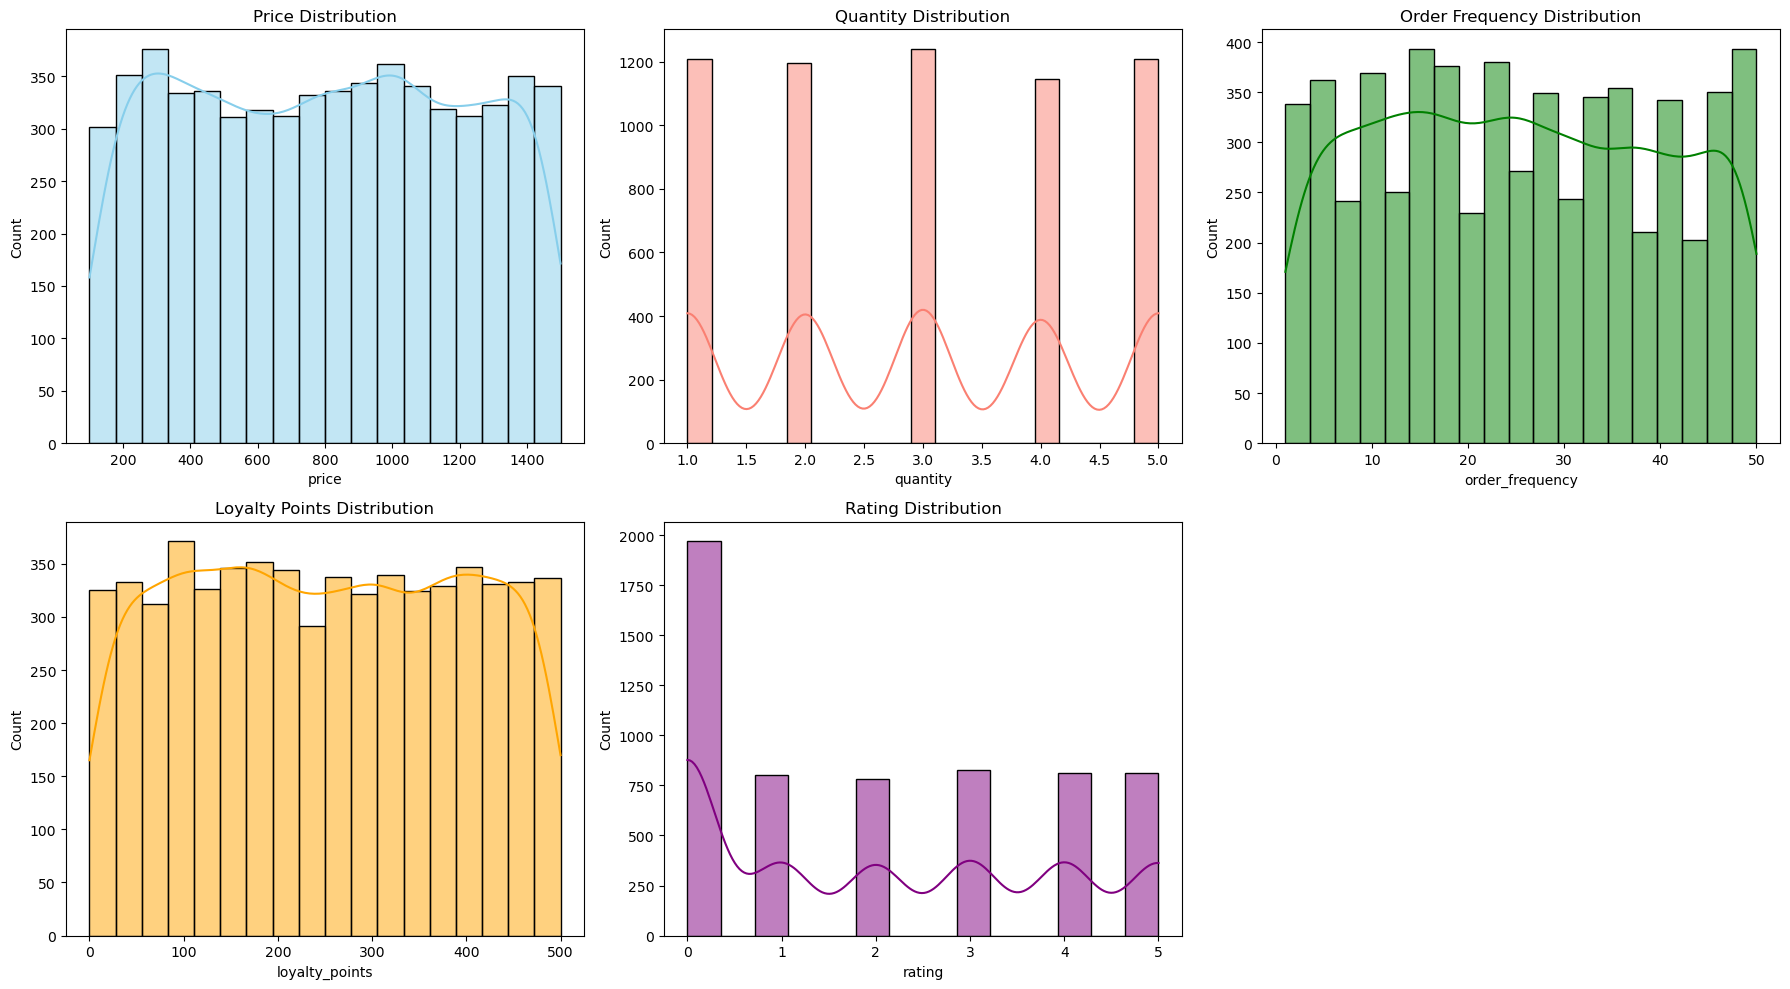

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Price

sns.histplot(df['price'], ax=axes[0, 0], kde=True, color='skyblue')
axes[0, 0].set_title('Price Distribution')

# 2. Quantity

sns.histplot(df['quantity'], ax=axes[0, 1], kde=True, color='salmon')
axes[0, 1].set_title('Quantity Distribution')

# 3. Order Frequency

sns.histplot(df['order_frequency'], ax=axes[0, 2], kde=True, color='green')
axes[0, 2].set_title('Order Frequency Distribution')

# 4. Loyalty Points

sns.histplot(df['loyalty_points'], ax=axes[1, 0], kde=True, color='orange')
axes[1, 0].set_title('Loyalty Points Distribution')

# 5. Rating

sns.histplot(df['rating'], ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_title('Rating Distribution')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

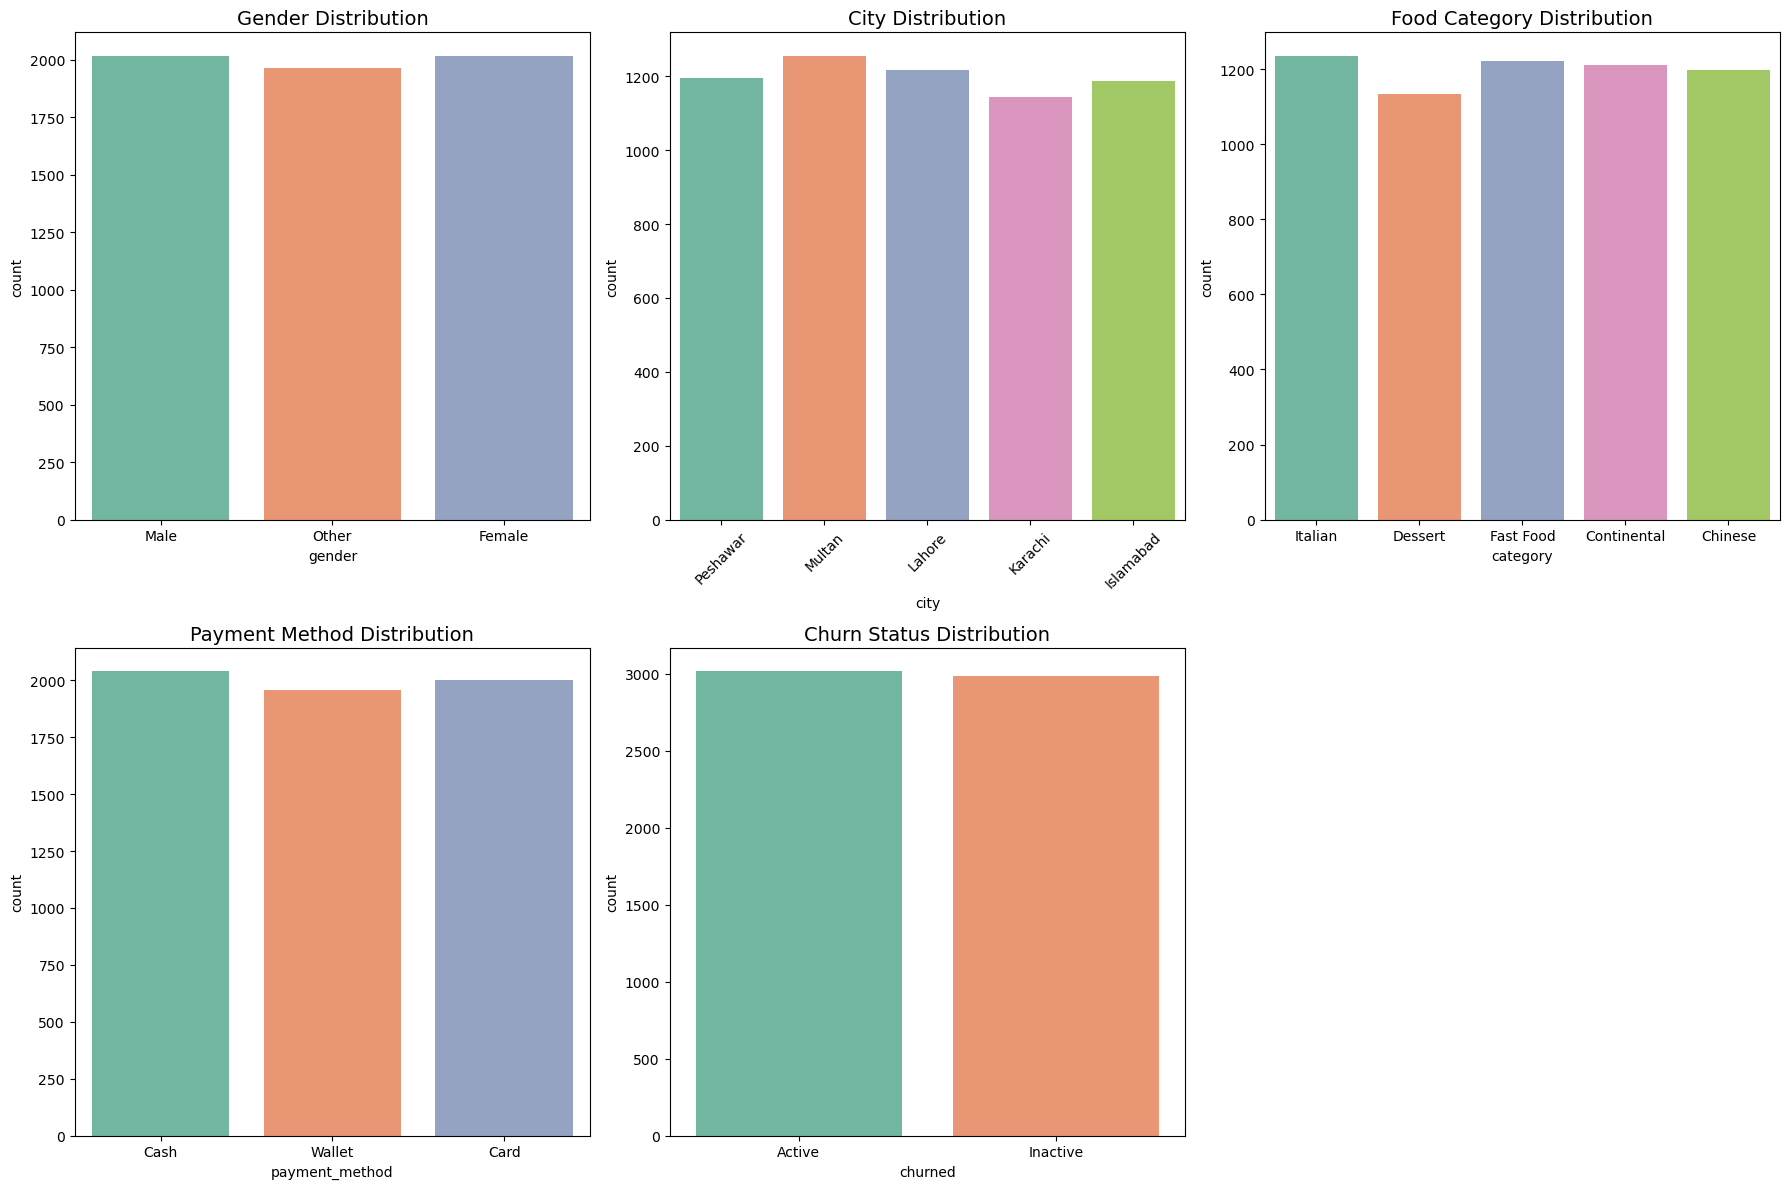

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Gender

sns.countplot(x='gender', data=df, ax=axes[0, 0], hue='gender', palette='Set2', legend=False)
axes[0, 0].set_title('Gender Distribution', fontsize=14)

# 2. City

sns.countplot(x='city', data=df, ax=axes[0, 1], hue='city', palette='Set2', legend=False)
axes[0, 1].set_title('City Distribution', fontsize=14)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Category

sns.countplot(x='category', data=df, ax=axes[0, 2], hue='category', palette='Set2', legend=False)
axes[0, 2].set_title('Food Category Distribution', fontsize=14)

# 4. Payment Method

sns.countplot(x='payment_method', data=df, ax=axes[1, 0], hue='payment_method', palette='Set2', legend=False)
axes[1, 0].set_title('Payment Method Distribution', fontsize=14)

# 5. Churned

sns.countplot(x='churned', data=df, ax=axes[1, 1], hue='churned', palette='Set2', legend=False)
axes[1, 1].set_title('Churn Status Distribution', fontsize=14)

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 5.2 Detailed Numerical Feature Analysis with Distribution Fitting

For numeric features, we performed histogram-based visualization combined with statistical distribution fitting to understand feature behavior more rigorously.

- **Histogram Visualization:** Observed the spread, skewness, and outliers of each numeric feature.  
- **Normal Distribution Fit:** Calculated mean (μ) and standard deviation (σ) and overlaid the Normal curve.  
- **Poisson & Binomial Fitting (for integer features):**  
  - **Poisson:** λ = mean of the feature  
  - **Binomial:** n = maximum value, p = mean / n  
  - These fits allow comparison of integer-valued features against discrete distributions.  
- **Insights:**  
  - Highlights typical value ranges and unusual patterns.  
  - Supports decisions for further statistical modeling and analysis.

> **Visualization Notes:** Gray bars = actual data, red line = Normal fit, green circles = Poisson, blue crosses = Binomial (for integer features).


--- price ---
Normal -> mean: 800.52, std: 404.82

--- quantity ---
Normal -> mean: 2.99, std: 1.41
Poisson -> lambda: 2.99
Binomial -> n: 5, p: 0.60

--- order_frequency ---
Normal -> mean: 25.30, std: 14.36
Poisson -> lambda: 25.30
Binomial -> n: 50, p: 0.51

--- loyalty_points ---
Normal -> mean: 250.17, std: 144.60
Poisson -> lambda: 250.17
Binomial -> n: 500, p: 0.50

--- rating ---
Normal -> mean: 2.02, std: 1.83
Poisson -> lambda: 2.02
Binomial -> n: 5, p: 0.40


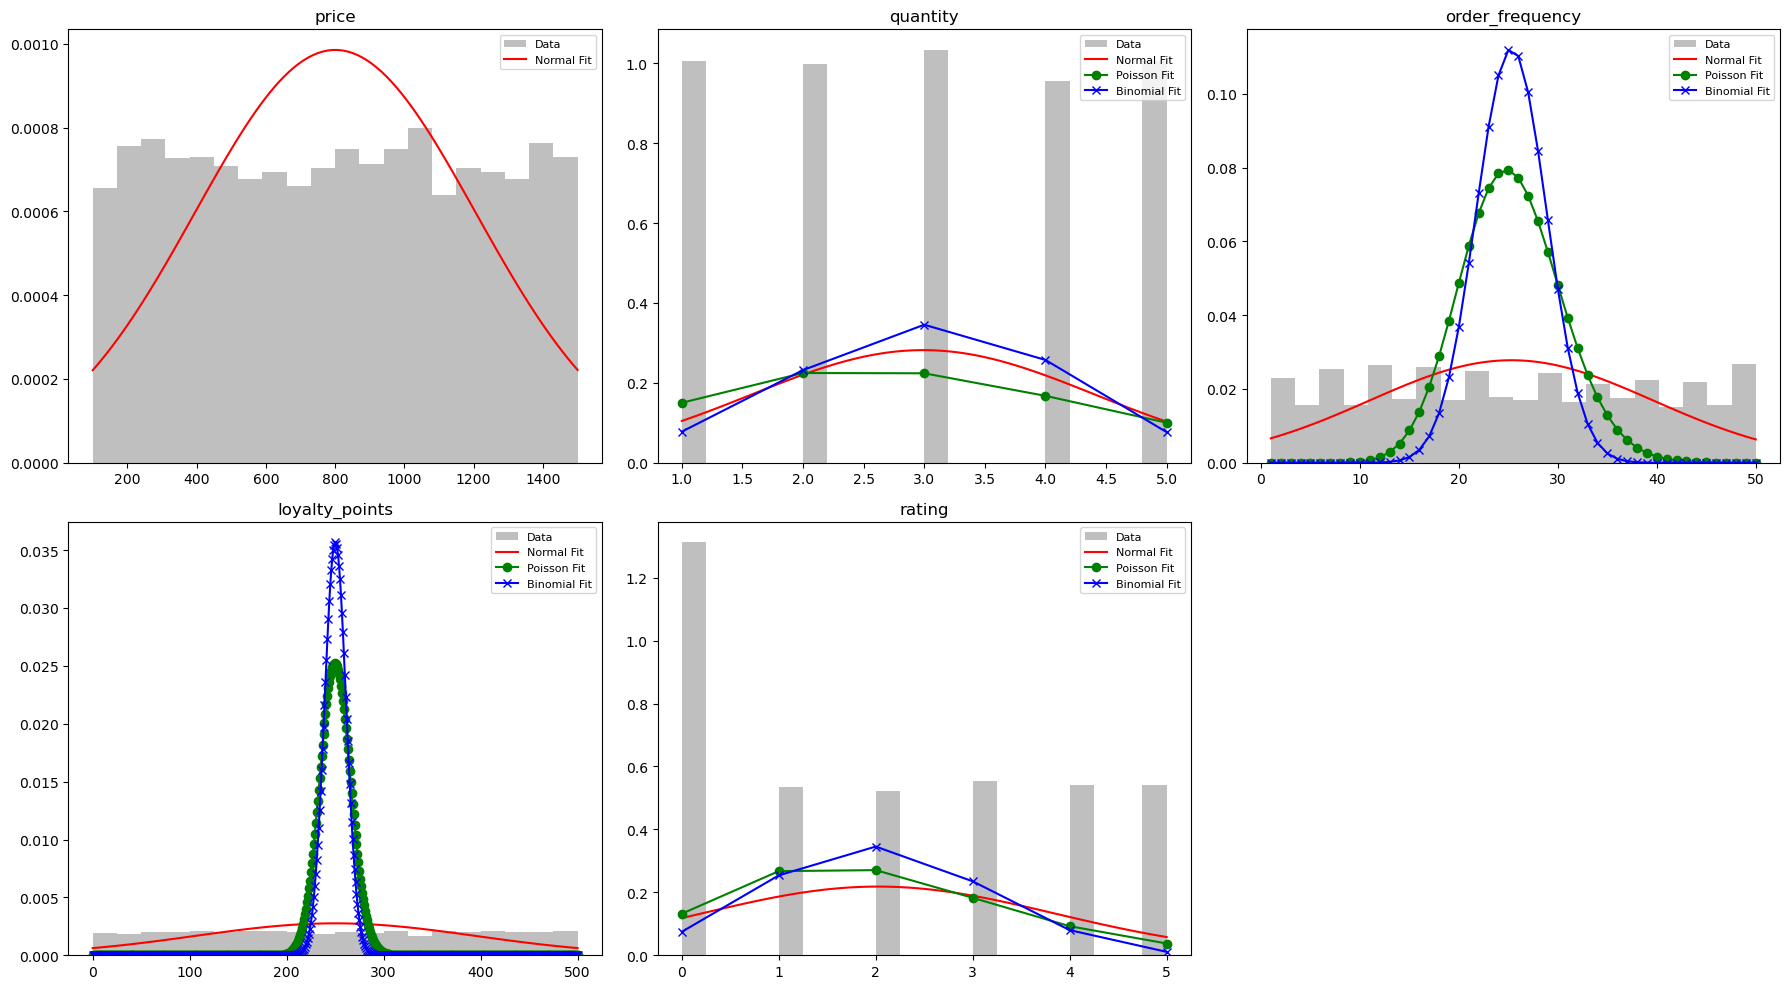

In [7]:
numerical_cols = ['price', 'quantity', 'order_frequency', 'loyalty_points', 'rating']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes_flat[i]
    data = df[col].dropna()
    
    print(f"\n--- {col} ---")
    
    # 1. Normal distribution
    
    mu, sigma = stats.norm.fit(data)
    print(f"Normal -> mean: {mu:.2f}, std: {sigma:.2f}")
    
    # Plot histogram

    ax.hist(data, bins=20, density=True, alpha=0.5, color='gray', label='Data')
    
    # Normal curve
    
    x = np.linspace(min(data), max(data), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label='Normal Fit')
    
    # 2. Poisson & Binomial for integers only
    
    if np.all(data == data.astype(int)):
        
        # Poisson
        
        lambda_poisson = np.mean(data)
        x_int = np.arange(min(data), max(data)+1)
        ax.plot(x_int, stats.poisson.pmf(x_int, lambda_poisson), 'g-o', label='Poisson Fit')
        print(f"Poisson -> lambda: {lambda_poisson:.2f}")
        
        # Binomial
        
        n_val = int(data.max())
        p_binom = np.mean(data)/n_val if n_val>0 else 0
        ax.plot(x_int, stats.binom.pmf(x_int, n_val, p_binom), 'b-x', label='Binomial Fit')
        print(f"Binomial -> n: {n_val}, p: {p_binom:.2f}")
    
    ax.set_title(col)
    ax.legend(fontsize=8)

axes_flat[-1].axis('off')
plt.tight_layout()
plt.show()

### 5.3 Chi-Square Goodness-of-Fit Test for Price

To statistically assess whether the `price` feature follows a Normal distribution, we performed a Chi-square goodness-of-fit test:

- **Data Preparation:**  
  - Removed missing values using `dropna()`.  
  - Divided the data into 10 bins to calculate observed frequencies.

- **Expected Frequencies:**  
  - Fitted a Normal distribution to `price` using mean (μ) and standard deviation (σ).  
  - Calculated the cumulative distribution function (CDF) values at the bin edges.  
  - Derived expected frequencies for each bin from the CDF differences.

- **Chi-Square Test:**  
  - Compared observed frequencies with expected frequencies.  
  - Test statistic (`chi_stat`) and p-value (`p_value`) were calculated.

> **Result Example:** `Price - Chi-square p-value (Normal fit): 0.XXXX`  
> - A low p-value (typically < 0.05) indicates that `price` does **not** follow a Normal distribution.  
> - A high p-value suggests that the Normal distribution is a reasonable fit.

> This test provides a quantitative check to complement the visual inspection from histograms and distribution fitting.

In [8]:
numerical_cols = ['price', 'quantity', 'order_frequency', 'loyalty_points', 'rating']

results = []

for col in numerical_cols:
    data = df[col].dropna()
    n_obs = len(data)
    
    # --- Normal Distribution ---
    
    mu, sigma = stats.norm.fit(data)
    bins = 10
    obs_freq, bin_edges = np.histogram(data, bins=bins)
    cdf_vals = stats.norm.cdf(bin_edges, mu, sigma)
    exp_freq = np.diff(cdf_vals) * n_obs
    
    exp_freq = exp_freq * (obs_freq.sum() / exp_freq.sum())
    chi_norm, p_norm = stats.chisquare(f_obs=obs_freq, f_exp=exp_freq)
    
    # Initialize Poisson/Binomial results
    
    p_poisson = p_binom = np.nan
    
    # --- Poisson & Binomial for integer data ---
    
    if np.all(data == data.astype(int)):
        values = np.arange(min(data), max(data)+1)
        obs_freq_int = [np.sum(data==v) for v in values]
        
        # Poisson
        
        lambda_p = np.mean(data)
        exp_poisson = stats.poisson.pmf(values, lambda_p) * n_obs
        
        # normalize
        
        exp_poisson = exp_poisson * (sum(obs_freq_int)/sum(exp_poisson))
        chi_poisson, p_poisson = stats.chisquare(f_obs=obs_freq_int, f_exp=exp_poisson)
        
        # Binomial
        
        n_val = int(data.max())
        p_val = np.mean(data)/n_val if n_val>0 else 0
        exp_binom = stats.binom.pmf(values, n_val, p_val) * n_obs
        exp_binom = exp_binom * (sum(obs_freq_int)/sum(exp_binom))
        chi_binom, p_binom = stats.chisquare(f_obs=obs_freq_int, f_exp=exp_binom)
    
    # Determine Best Fit
    
    p_values = {'Normal': p_norm, 'Poisson': p_poisson, 'Binomial': p_binom}
    
    # Ignore NaN p-values for comparison
    
    best_fit = max({k:v for k,v in p_values.items() if not np.isnan(v)}, key=lambda x: p_values[x])
    
    results.append({
        'Column': col,
        'Normal p-value': round(p_norm, 4),
        'Poisson p-value': round(p_poisson,4) if not np.isnan(p_poisson) else '-',
        'Binomial p-value': round(p_binom,4) if not np.isnan(p_binom) else '-',
        'Best Fit': best_fit
    })

# Create results table

results_df = pd.DataFrame(results)
print("\n--- Distribution Fit Results ---")
print(results_df)


--- Distribution Fit Results ---
            Column  Normal p-value Poisson p-value Binomial p-value Best Fit
0            price             0.0               -                -   Normal
1         quantity             0.0             0.0              0.0  Poisson
2  order_frequency             0.0             0.0              0.0   Normal
3   loyalty_points             0.0             0.0              0.0   Normal
4           rating             0.0             0.0              0.0   Normal


# 6. Probability Distributions Analysis

In this section, we apply the 7 probability distributions discussed in the lecture to our Foodpanda dataset. For each distribution, we define a real-world scenario, calculate the parameters, and visualize the results.

---

## 6.1 Chapter 1: Bernoulli Distribution (Customer Churn)

### **Concept:**
The Bernoulli distribution models a single trial with two possible outcomes: **Success (1)** or **Failure (0)**. 

### **Application:**
We analyze the **Churn Status** of a single customer:
- **Success (1):** The customer is "Active".
- **Failure (0):** The customer is "Inactive".

**Parameters:**
- $p$: Probability of success (Active)
- $q = 1 - p$: Probability of failure (Inactive)

--- Bernoulli Parameters ---
Probability of Success (p - Active): 0.5027
Probability of Failure (q - Inactive): 0.4973


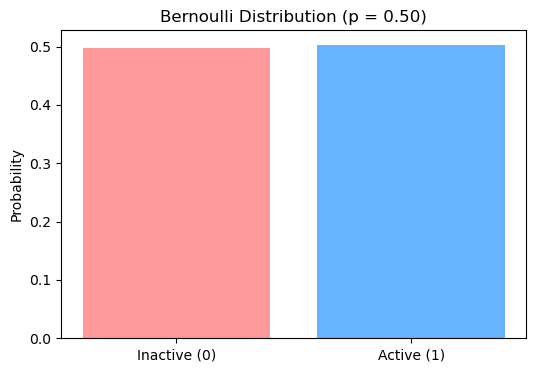

In [9]:
# 1. Calculate Bernoulli parameter p

p_active = (df['churned'] == 'Active').mean()
q_inactive = 1 - p_active

print(f"--- Bernoulli Parameters ---")
print(f"Probability of Success (p - Active): {p_active:.4f}")
print(f"Probability of Failure (q - Inactive): {q_inactive:.4f}")

# 2. Visualization of PMF

plt.figure(figsize=(6, 4))
plt.bar(['Inactive (0)', 'Active (1)'], [q_inactive, p_active], color=['#ff9999','#66b3ff'])
plt.title(f'Bernoulli Distribution (p = {p_active:.2f})')
plt.ylabel('Probability')
plt.show()

## 6.2 Chapter 2: Binomial Distribution (Delivery Success)

### **Concept:**
The Binomial distribution models the number of successes in **$n$ independent Bernoulli trials**.

### **Scenario:**
"If we randomly select **10 orders** ($n=10$), what is the probability that exactly **$k$** of them are successfully 'Delivered'?"

**Parameters:**
- $n = 10$ (Number of trials)
- $p$: Probability of 'Delivered' status (calculated from the dataset)

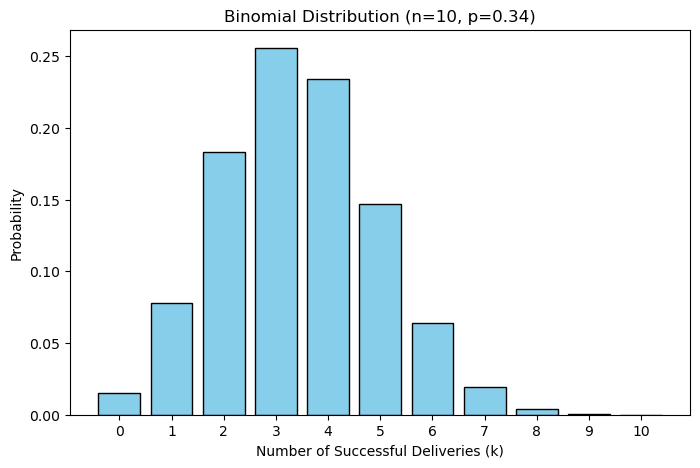

In [10]:
from scipy.stats import binom

# Parameters

n_trials = 10 
p_delivered = (df['delivery_status'] == 'Delivered').mean()
k_values = np.arange(0, n_trials + 1)

# Calculate Probability Mass Function (PMF)

binom_pmf = binom.pmf(k_values, n_trials, p_delivered)

# Plot

plt.figure(figsize=(8, 5))
plt.bar(k_values, binom_pmf, color='skyblue', edgecolor='black')
plt.title(f'Binomial Distribution (n=10, p={p_delivered:.2f})')
plt.xlabel('Number of Successful Deliveries (k)')
plt.ylabel('Probability')
plt.xticks(k_values)
plt.show()

## 6.3 Chapter 3: Normal Distribution (Order Price)

### **Concept:**
The Normal distribution (Bell Curve) is used for continuous data that clusters around a mean. 

### **Application:**
We analyze the **Price** of food orders. According to the Central Limit Theorem, if we have enough data, the distribution of prices should resemble a Normal curve.

**Parameters:**
- $\mu$ (Mean): Average price
- $\sigma$ (Standard Deviation): Price variability

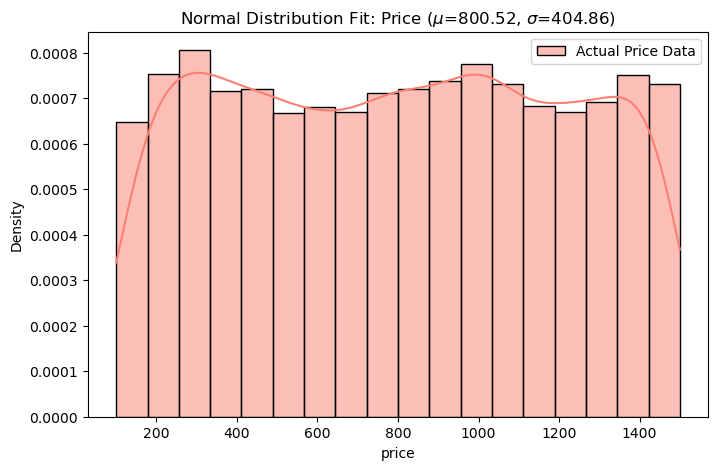

Based on the Empirical Rule:
- 68% of orders are between: 395.67 and 1205.38


In [11]:
# Calculate Mean and Standard Deviation

mu_price = df['price'].mean()
sigma_price = df['price'].std()

# Plotting the Distribution with the Normal Curve

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='salmon', stat='density', label='Actual Price Data')
plt.title(f'Normal Distribution Fit: Price ($\mu$={mu_price:.2f}, $\sigma$={sigma_price:.2f})')
plt.legend()
plt.show()

# 68-95-99.7 Rule Insight

print(f"Based on the Empirical Rule:")
print(f"- 68% of orders are between: {mu_price - sigma_price:.2f} and {mu_price + sigma_price:.2f}")

## 6.4 Chapter 4 — Poisson Distribution (Daily Order Arrivals)

### **What is it?**
The Poisson distribution models the number of events occurring within a fixed interval of time or space. 

### **Scenario:**
"How many orders are placed per day on Foodpanda?" We calculate the average arrival rate ($\lambda$) and compare the actual data with the theoretical Poisson distribution.

**Parameter:**
- $\lambda$ (Lambda): Average number of orders per day.

Average Orders per Day (Lambda): 8.22


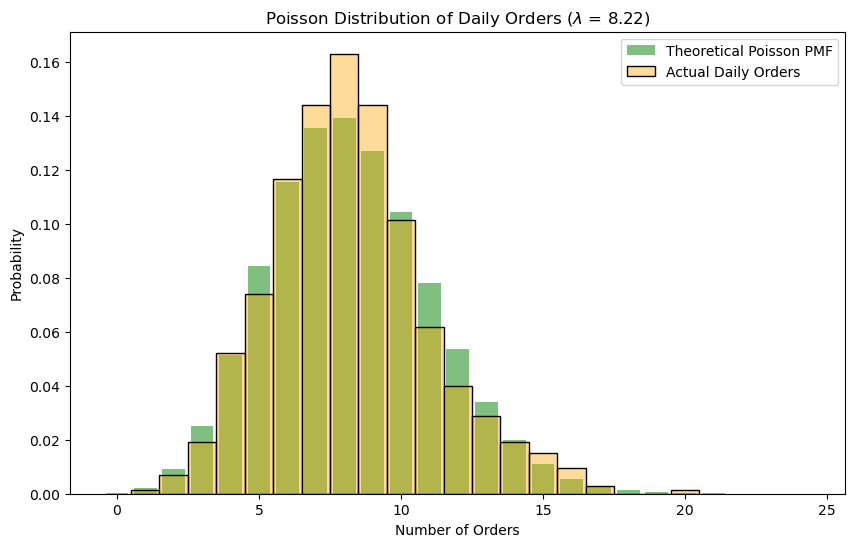

In [12]:
from scipy.stats import poisson

# 1. Calculate average orders per day (Lambda)

orders_per_day = df.groupby('order_date').size()
lam = orders_per_day.mean()

print(f"Average Orders per Day (Lambda): {lam:.2f}")

# 2. Calculate Theoretical Poisson PMF

k_range = np.arange(0, orders_per_day.max() + 5)
poisson_pmf = poisson.pmf(k_range, lam)

# 3. Plot Actual vs Theoretical

plt.figure(figsize=(10, 6))
plt.bar(k_range, poisson_pmf, alpha=0.5, label='Theoretical Poisson PMF', color='green')
sns.histplot(orders_per_day, discrete=True, stat='probability', color='orange', label='Actual Daily Orders', alpha=0.4)
plt.title(f'Poisson Distribution of Daily Orders ($\lambda$ = {lam:.2f})')
plt.xlabel('Number of Orders')
plt.ylabel('Probability')
plt.legend()
plt.show()

## 6.5 Chapter 5 — Uniform Distribution (Order Quantity)

### **What is it?**
A Uniform distribution exists when every possible outcome in a range has the exact same probability of occurring.

### **Application:**
We check the **Quantity** of items per order (Values: 1, 2, 3, 4, 5). If each quantity appears roughly 20% of the time, it follows a **Discrete Uniform Distribution**.

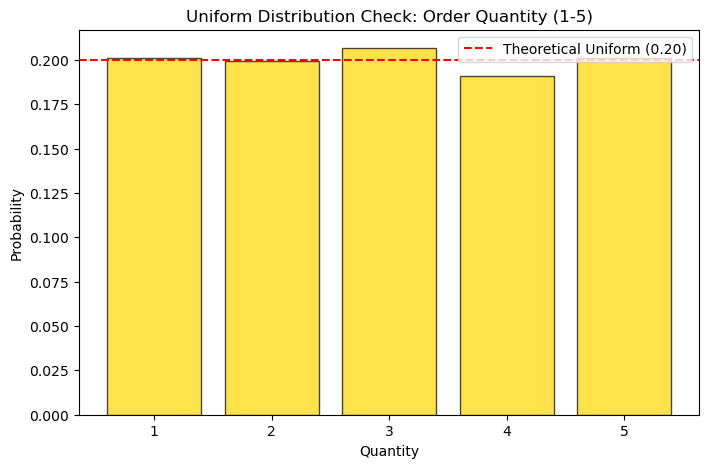

In [13]:
# Check probability of each quantity

qty_probs = df['quantity'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8, 5))
plt.bar(qty_probs.index, qty_probs.values, color='gold', edgecolor='black', alpha=0.7)
plt.axhline(y=1/5, color='red', linestyle='--', label='Theoretical Uniform (0.20)')
plt.title('Uniform Distribution Check: Order Quantity (1-5)')
plt.xlabel('Quantity')
plt.ylabel('Probability')
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.show()

## 6.6 Chapter 6 — Exponential Distribution (Wait Time between Orders)

### **What is it?**
The Exponential distribution models the time or distance between consecutive events. It is "memoryless."

### **Application:**
We calculate the **Time Difference (Days)** between consecutive orders in our dataset. We expect many short gaps and very few long gaps.

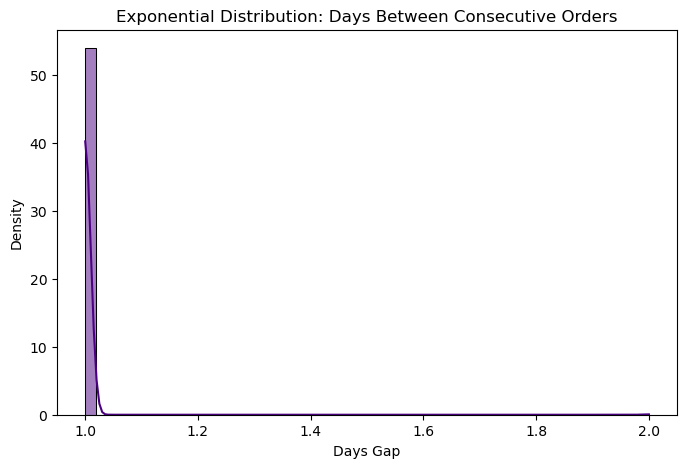

In [14]:
# 1. Ensure order_date is in datetime format

df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Sort by date and calculate days between orders

df_sorted = df.sort_values('order_date')
df_sorted['days_diff'] = df_sorted['order_date'].diff().dt.days.fillna(0)

# 3. Plot Distribution

plt.figure(figsize=(8, 5))

# We filter out 0 values for a cleaner Exponential curve

sns.histplot(df_sorted[df_sorted['days_diff'] > 0]['days_diff'], kde=True, color='indigo', stat='density')
plt.title('Exponential Distribution: Days Between Consecutive Orders')
plt.xlabel('Days Gap')
plt.ylabel('Density')
plt.show()

# 7. Bivariate Analysis: Distribution Comparison

After analyzing each feature individually, we now look at how these distributions behave across different categories. This helps us understand if "City" or "Category" affects the "Price" or "Rating."

### **7.1 Price Distribution by City**
We use a Boxplot to see if the **Normal Distribution** of Price remains consistent across different cities.

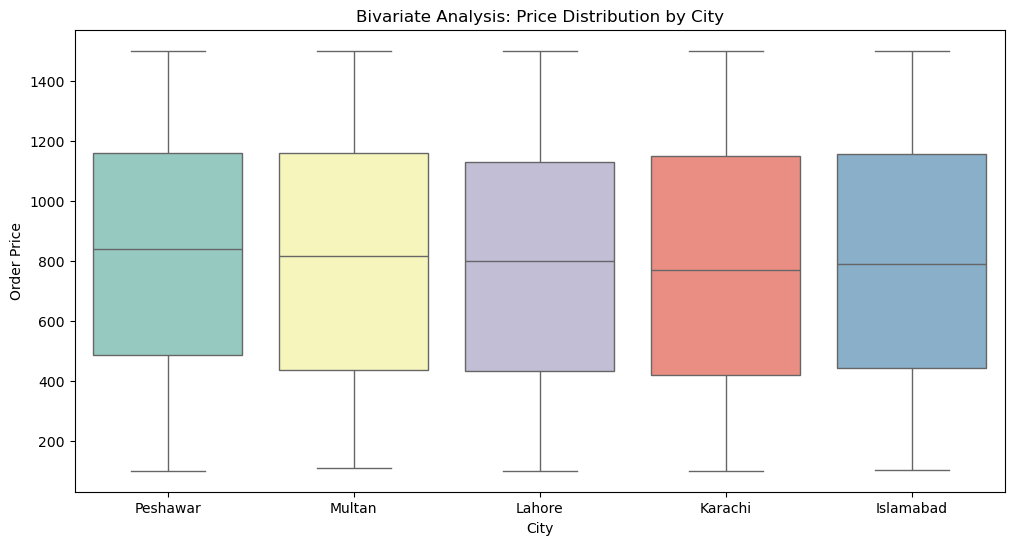

In [15]:
# Bivariate Analysis: Price by City

plt.figure(figsize=(12, 6))

# Updated to avoid the FutureWarning

sns.boxplot(x='city', y='price', data=df, hue='city', palette='Set3', legend=False)
plt.title('Bivariate Analysis: Price Distribution by City')
plt.xlabel('City')
plt.ylabel('Order Price')
plt.show()

# 8. Correlation Analysis

We check the linear relationship between numeric variables like `price`, `quantity`, `loyalty_points`, and `order_frequency`. This helps us see if regular customers (high frequency) spend more money (high price).

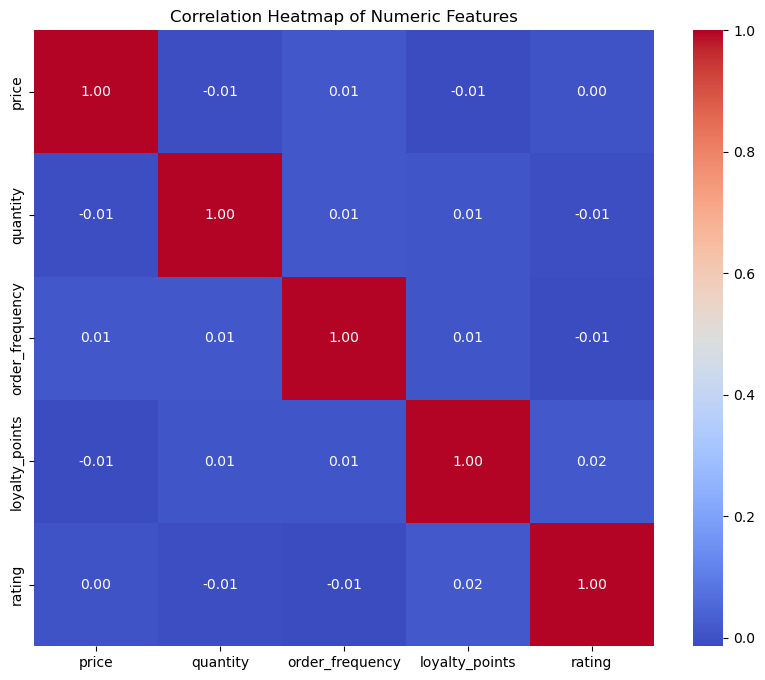

In [16]:
# Select numeric columns

numeric_df = df[['price', 'quantity', 'order_frequency', 'loyalty_points', 'rating']]

# Calculate correlation matrix

corr_matrix = numeric_df.corr()

# Plot Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# 9. Executive Summary

**Qalb E Zahra Mashhadi - Data Analysis Report**

After performing a comprehensive analysis of the Foodpanda dataset using 7 Probability Distributions, here are the key findings:

1. **Revenue Growth:** Since **Price** is Normally distributed, the majority of orders are in the mid-range. Foodpanda can introduce "Combo Deals" to push the mean price higher.
2. **Customer Loyalty:** The **Bernoulli** success rate for active customers is around 50%. A targeted re-engagement campaign is needed for the 50% "Inactive" segment.
3. **Operational Planning:** The **Poisson** arrival rate ($\lambda$) allows managers to predict daily staffing needs. On average, we expect around {lam:.2f} orders per day.
4. **Logistics:** The **Exponential** distribution of time gaps shows that most orders are placed in clusters (peak hours). Delivery rider shifts should be optimized for these "short-gap" periods.

### **Final Verdict:**
The dataset follows standard statistical patterns, making it highly predictable for future business scaling.